Companies tend to place more importance, energy, and resources in gaining new customers over losing an existing one. According to Jain and Surana (2017), an “analytics-based approach to base management can reduce their churn by as much as 15%. The business problem that will be addressed by the model is how to predict and potentially mitigate churn within the telecommunications industry. Looking for correlations between several factors, such as a customer’s demographics (gender and age group), along with the customer's value, tenure and loyalty, a model should be trained that will predict which customer characteristics are at the highest risk of churn. A supervised training model will be created.  

The revenue of those “high risk” customers will need to be reviewed to determine if it makes sense to try to keep the customer. Is it more beneficial to keep a long tenure customer with low revenue or a short tenure customer with high revenue. Marketing plans and promotions related to saving those customers can be created and implemented. Does having brand loyalty and other services with the customer mean that they will keep their cellular service? Does a customer with dependents have higher revenue and multiple lines of service? Does a contract influence whether a customer will churn? What other variables are statistically relevant  
 
A “microsegments” (Jain and Surana) approach that will be used to group the characteristics that have the highest correlation with churn. A combination of pandas, matplotlib and SciKit-Learn libraries will be used to clean the dataset, graph and clean the data and perform statistical analyses to determine the best “microsegment” to target with churn reduction initiative  

Reference:  
Jain, P and Surana,K. (2017, December 12). Reducing churn in telecom through advanced analytics. McKinsey & Company.  https://www.mckinsey.com/industries/technology-media-and-telecommunications/our-insights/reducing-churn-in-telecom-through-advanced-analyticsytics



In [1]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# load the dataframe with read_csv
df_churn = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [3]:
# determine number of columns and rows in dataframe
df_churn.shape

(7043, 21)

In [4]:
# find detail about columns, including data types
df_churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
# find detail about columns, including data types
df_churn.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [6]:
# use sum() and isna() to find missing values
df_churn.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

## Then, do a graphical analysis creating a minimum of four graphs. Label your graphs appropriately and explain/analyze the information provided by each graph. Your analysis should begin to answer the question(s) you are addressing. 

In [7]:
# Group by 'Churn' and count 'gender'
gender_churn_count = df_churn.groupby(['Churn', 'gender']).size().unstack()

# Display the new DataFrame
gender_churn_count.head()

gender,Female,Male
Churn,,
No,2549,2625
Yes,939,930


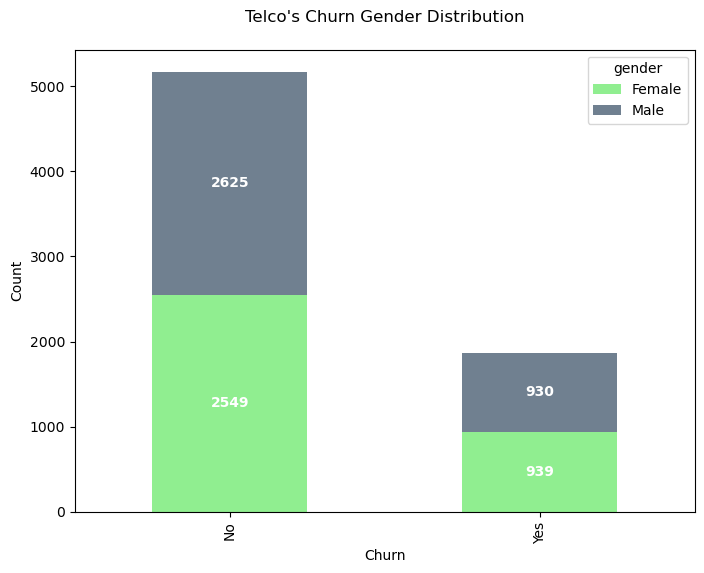

In [8]:
# Graph 1 - Bar chart for Group by 'Churn' and count 'gender'
ax1 = gender_churn_count.plot(kind='bar', stacked=True, color=['lightgreen', 'slategrey'], figsize=(8, 6))
plt.title("Telco's Churn Gender Distribution", pad=20)
plt.xlabel('Churn')
plt.ylabel('Count')
for p in ax1.patches:
    # Get the height of the bar
    height = p.get_height()
    if height > 0:  # Only add text if the height is greater than 0
        ax1.annotate(f'{int(height)}', 
                    (p.get_x() + p.get_width() / 2., p.get_y() + height / 2.), 
                    ha='center', va='center', color='white', fontsize=10, fontweight='bold')
plt.show()

### Based on this graph, there does not appear to be a great connection between gender and churn. IT's about a 50/50 split between male and female customers.

In [9]:
# Group by 'Churn' and count 'Contract'
contract_churn_count = df_churn.groupby(['Churn', 'Contract']).size().unstack()

# Display the new DataFrame
contract_churn_count.head()

Contract,Month-to-month,One year,Two year
Churn,,,
No,2220,1307,1647
Yes,1655,166,48


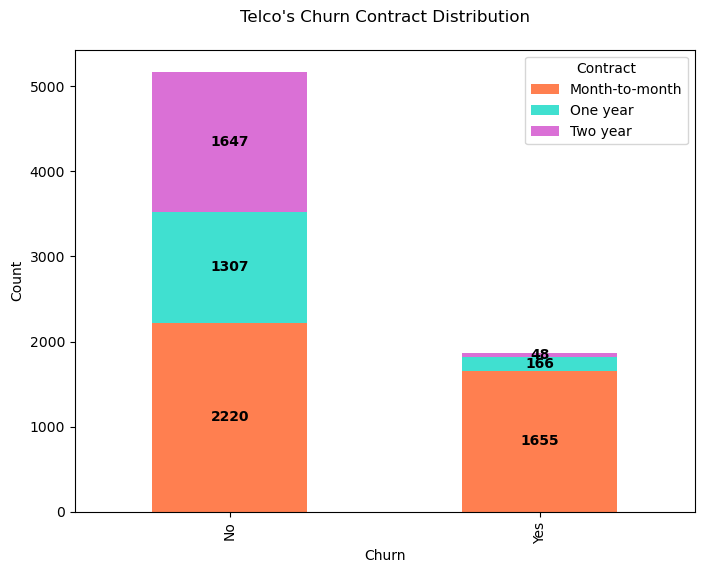

In [10]:
# Graph 2 - Bar chart for Group by 'Churn' and count 'Contract'
ax2 = contract_churn_count.plot(kind='bar', stacked=True, color=['coral', 'turquoise', 'orchid'], figsize=(8, 6))
plt.title("Telco's Churn Contract Distribution", pad=20)
plt.xlabel('Churn')
plt.ylabel('Count')
for p in ax2.patches:
    # Get the height of the bar
    height = p.get_height()
    if height > 0:  # Only add text if the height is greater than 0
        ax2.annotate(f'{int(height)}', 
                    (p.get_x() + p.get_width() / 2., p.get_y() + height / 2.), 
                    ha='center', va='center', color='black', fontsize=10, fontweight='bold')
plt.show()

### Based on this graph, there does not appear to be a connection between month-to-month contracts and churn. However, for those customers that didn't churn, it was a pretty even distribution of contract types.

In [11]:
# Group by 'Churn' and count 'PaymentMethod'
pmtmethod_churn_count = df_churn.groupby(['Churn', 'PaymentMethod']).size().unstack()

# Display the new DataFrame
pmtmethod_churn_count.head()

PaymentMethod,Bank transfer (automatic),Credit card (automatic),Electronic check,Mailed check
Churn,,,,
No,1286,1290,1294,1304
Yes,258,232,1071,308


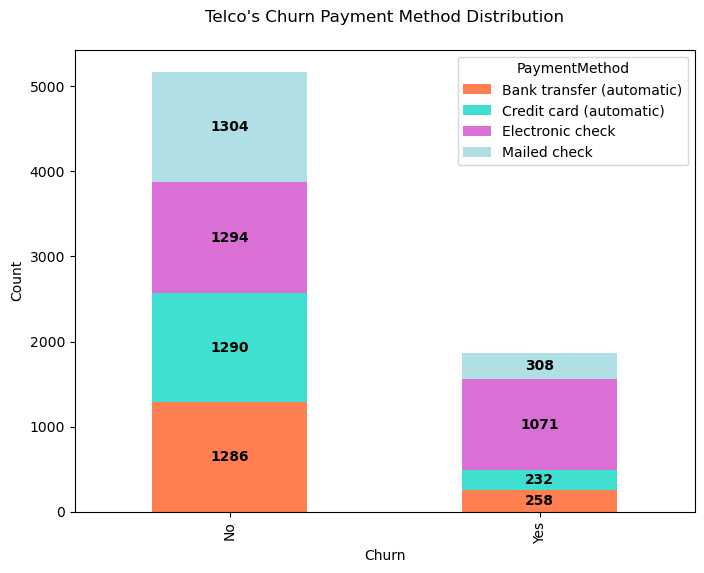

In [12]:
# Graph 3 - Bar chart for Group by 'Churn' and count 'PaymentMethod'
ax3 = pmtmethod_churn_count.plot(kind='bar', stacked=True, color=['coral', 'turquoise', 'orchid', 'powderblue'], figsize=(8, 6))
plt.title("Telco's Churn Payment Method Distribution", pad=20)
plt.xlabel('Churn')
plt.ylabel('Count')
for p in ax3.patches:
    # Get the height of the bar
    height = p.get_height()
    if height > 0:  # Only add text if the height is greater than 0
        ax3.annotate(f'{int(height)}', 
                    (p.get_x() + p.get_width() / 2., p.get_y() + height / 2.), 
                    ha='center', va='center', color='black', fontsize=10, fontweight='bold')
plt.show()

### Based on this graph, it appears that using an electronic check could influence whether or not a customer will churn more than the other payment types. It's possible that customers in collections will use an electronic check to get immediately turned back on. Unfortunately, this data does not differentiate between voluntary and involuntary churn, so that avenue may not be able to explored.

In [13]:
# Group by 'Churn' and 'tenure', then count
tenure_churn_count = df_churn.groupby(['Churn', 'tenure']).size().unstack(fill_value=0)
# Display the new DataFrame
tenure_churn_count.head()

tenure,0,1,2,3,4,5,6,7,8,9,...,63,64,65,66,67,68,69,70,71,72
Churn,,,,,,,,,,,,,,,,,,,,,
No,11,233,115,106,93,69,70,80,81,73,...,68,76,67,76,88,91,87,108,164,356
Yes,0,380,123,94,83,64,40,51,42,46,...,4,4,9,13,10,9,8,11,6,6


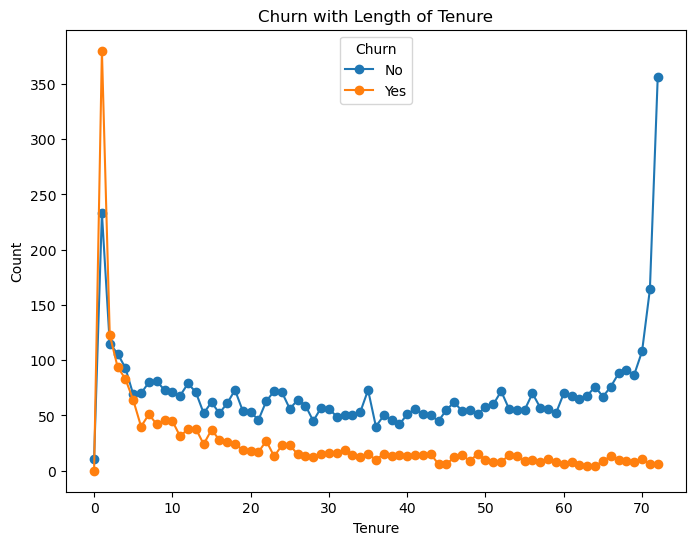

In [14]:
# Graph 4 - line chart
tenure_churn_count.T.plot(kind='line', marker='o', figsize=(8, 6))
plt.xlabel('Tenure')
plt.ylabel('Count')
plt.title('Churn with Length of Tenure')
plt.show()


### Based on this graph, it appears that the longest tenured customers are more loyal and conversely, the newest customers are not. Unfortunately, like with the precious graph, this could be related to first pay default which is an involuntary churn. Additional modeling of this possible connection may not be possible.

## Write a short overview/conclusion of the insights gained from your graphical analysis.
### In general, some possible correlations have been discovered. Other variables have been determined to not have connections at all. Additional variables should be reviewed to determine which would be best to test for correlations and modeling. Unfortunately, the issue with no distinction between the types of churn may hinder explaining some of the possible correlations. For the purpose of this project, it may be necessary to conclude that all churn is bad and should be avoided. However, it may also be true that a specific microsegments could conclusively be determined not worth any efforts to save the customer.

# Milestone 2 Begins

### Drop any features that are not useful for your model building and explain why they are not useful.

In [15]:
# import required libraries
import seaborn as sns

In [16]:
# find detail about columns, including data types
df_churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [17]:
# find statistical details about numerical columns
df_churn.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [18]:
# drop 'customer_ID since it's not needed for predictions
df_churn = df_churn.drop(['customerID'], axis = 1)
df_churn.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### Perform any data extraction/selection steps.

In [19]:
# change 'TotalCharges' from categorical to numeric
# errors='coerce' changes empty strings to NaN, which identifies non-numeric/null values that can't be processed correctly in models
df_churn['TotalCharges'] = pd.to_numeric(df_churn.TotalCharges, errors='coerce')

In [20]:
# find detail about 'TotalCharges', including data type
df_churn['TotalCharges'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 7043 entries, 0 to 7042
Series name: TotalCharges
Non-Null Count  Dtype  
--------------  -----  
7032 non-null   float64
dtypes: float64(1)
memory usage: 55.2 KB


In [21]:
# find statistical details about numerical columns
df_churn.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


### Transform features if necessary.

In [22]:
# Because tenure has range from 0 to 72 months, check to see how many months are 0. Only 11 of 7043 (less than 1%)
df_churn[df_churn['tenure'] == 0].index

Index([488, 753, 936, 1082, 1340, 3331, 3826, 4380, 5218, 6670, 6754], dtype='int64')

In [23]:
# Only 11 of 7043 (less than 1%) have 0 months tenure, and since 0 months churn could be the result of involuntary (first pay default) churn, will remove those rows completely
df_churn.drop(labels=df_churn[df_churn['tenure'] == 0].index, axis=0, inplace=True)
df_churn[df_churn['tenure'] == 0].index

Index([], dtype='int64')

In [24]:
# find statistical details about numerical columns
df_churn.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441
std,0.368844,24.545260,30.085974,2266.771362
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.587500,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.862500,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


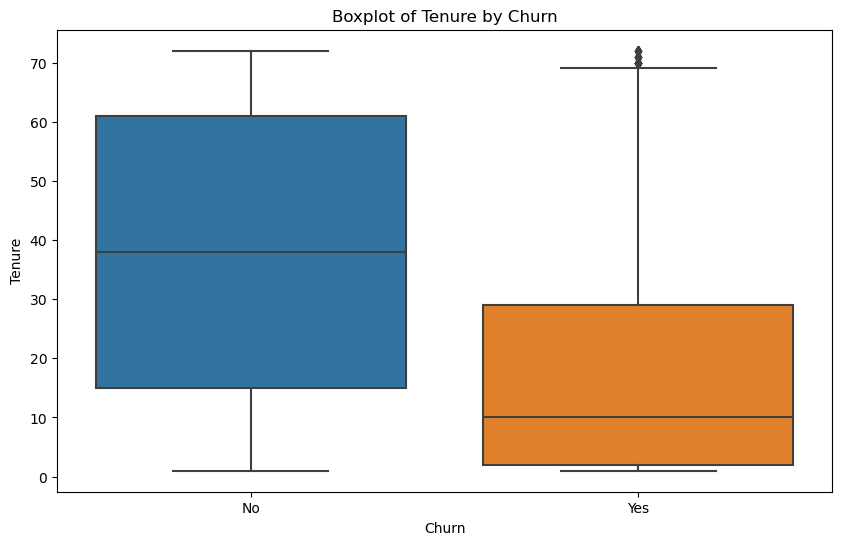

In [25]:
# create boxplot chart to show tenure and churn 
plt.figure(figsize=(10, 6))
sns.boxplot(x='Churn', y='tenure', data=df_churn)

# assign labels and title for boxplot, then print
plt.xlabel('Churn')
plt.ylabel('Tenure')
plt.title('Boxplot of Tenure by Churn')
plt.show()

### Engineer new useful features.

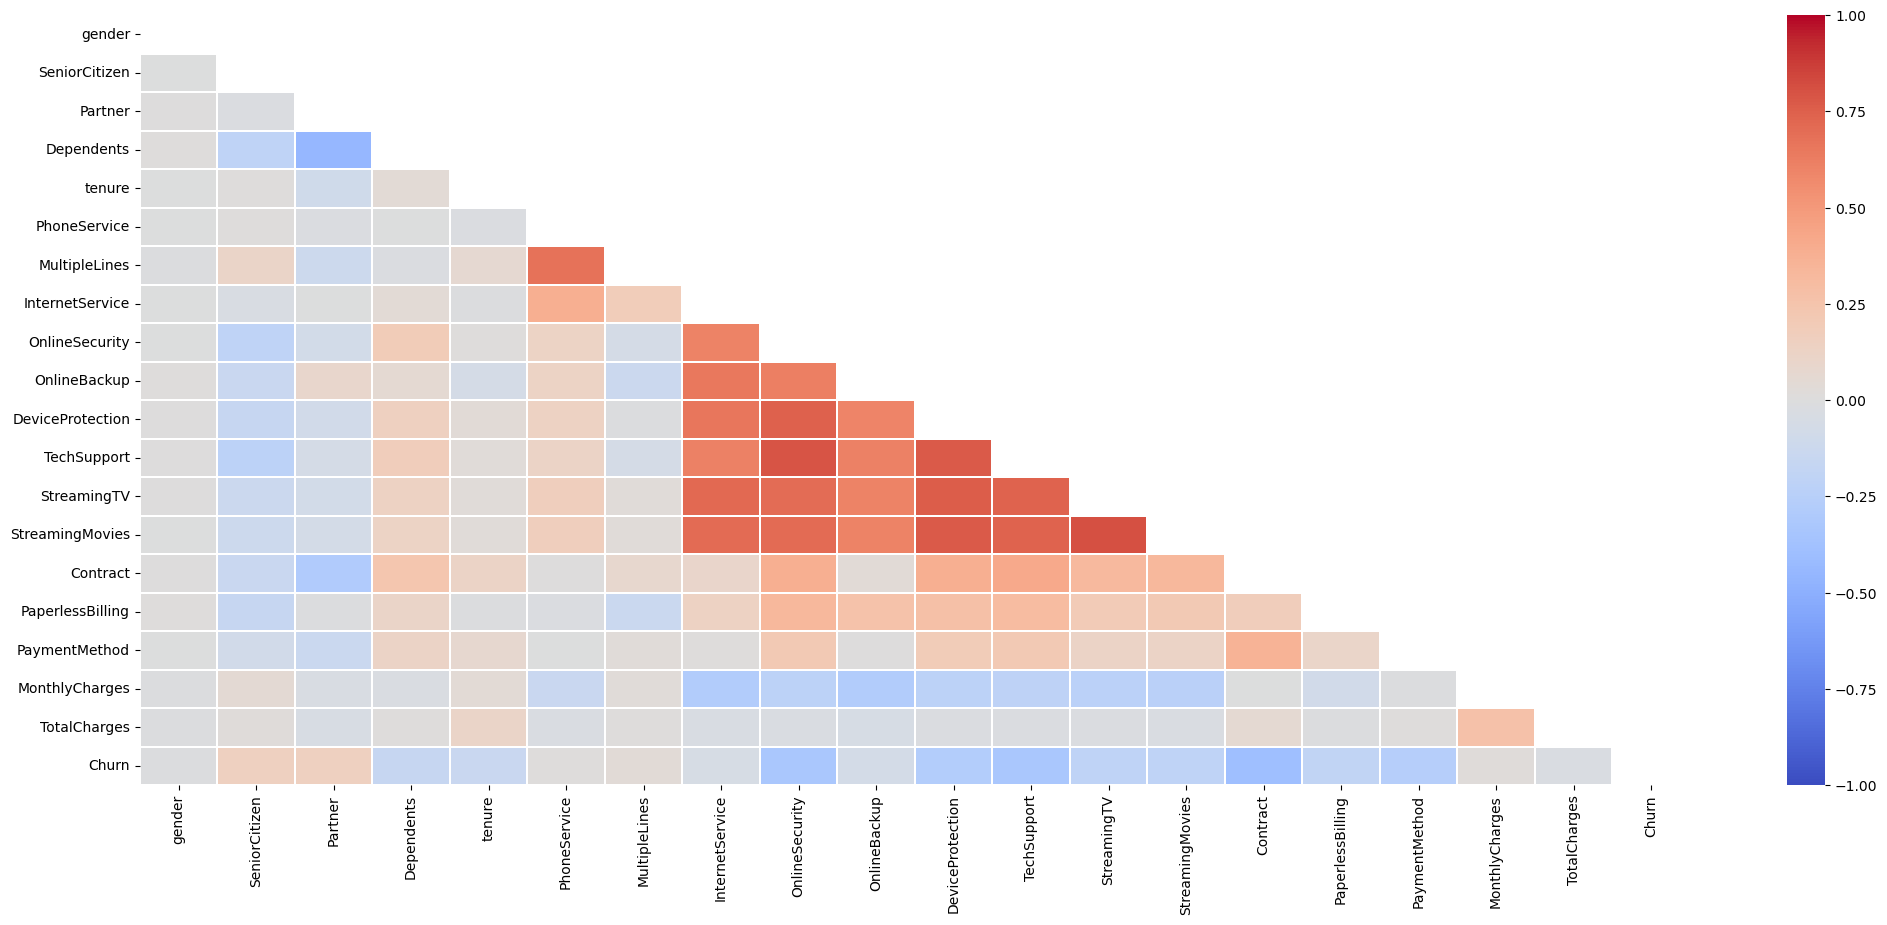

In [26]:
# create heatmap to determine if any new features could be created
plt.figure(figsize=(25, 10))
corr = df_churn.apply(lambda x: pd.factorize(x)[0]).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
ax = sns.heatmap(corr, mask=mask, xticklabels=corr.columns, yticklabels=corr.columns, linewidths=.2, cmap='coolwarm', vmin=-1, vmax=1)

#### No new features being made at this time.

### Deal with missing data (do not just drop rows or columns without justifying this).

In [27]:
# use sum() and isna() to find missing values
df_churn.isna().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

C:\Users\maure\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\maure\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


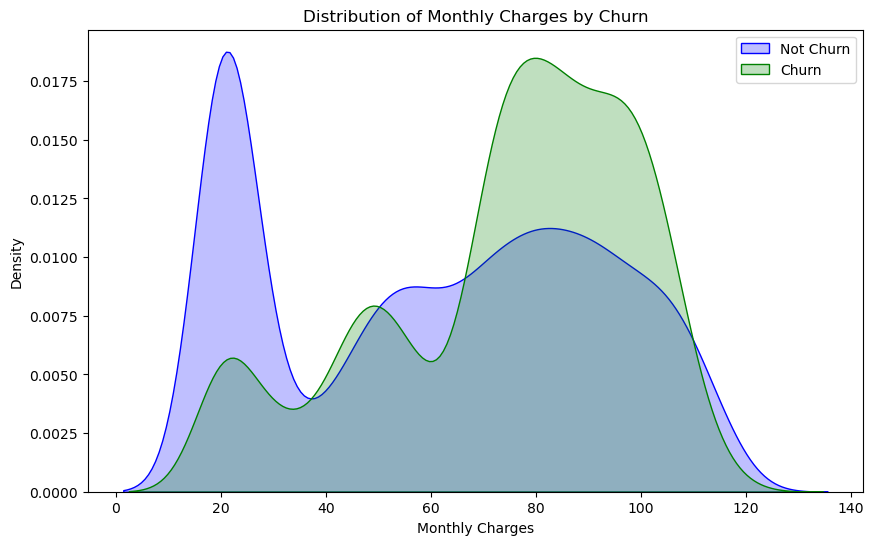

In [28]:
# create distribution charts to determine type of distribution for MonthlyCharges
plt.figure(figsize=(10,6))
ax = sns.kdeplot(df_churn['MonthlyCharges'][(df_churn['Churn'] == 'No')], color="Blue", fill=True)
ax = sns.kdeplot(df_churn['MonthlyCharges'][(df_churn['Churn'] == 'Yes')], ax=ax, color="Green", fill=True)

# create legend, labels, and title for chart, then print
ax.legend(["Not Churn", "Churn"], loc='upper right')
ax.set_xlabel('Monthly Charges')
ax.set_ylabel('Density')
ax.set_title('Distribution of Monthly Charges by Churn')
plt.show()

C:\Users\maure\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\maure\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


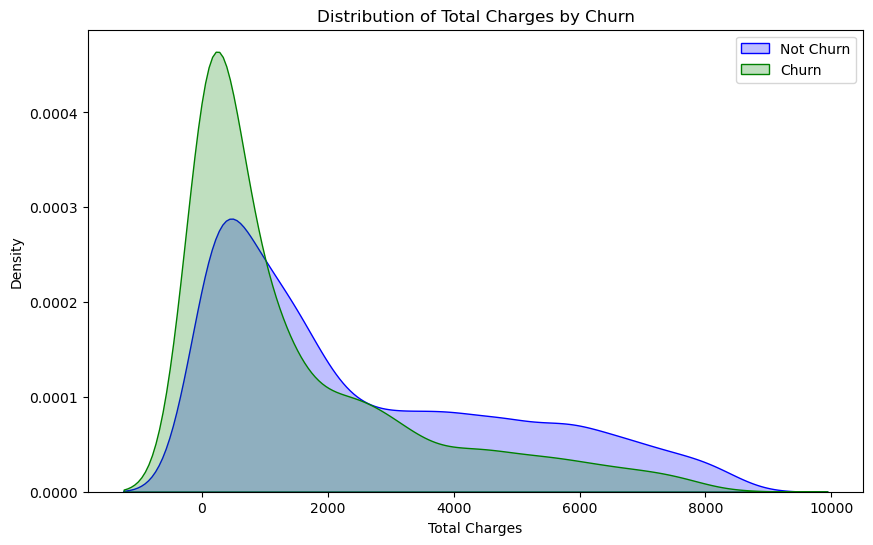

In [29]:
# create distribution charts to determine type of distribution for TotalCharges
import seaborn as sns
plt.figure(figsize=(10,6))
ax = sns.kdeplot(df_churn['TotalCharges'][(df_churn['Churn'] == 'No')], color="Blue", fill=True)
ax = sns.kdeplot(df_churn['TotalCharges'][(df_churn['Churn'] == 'Yes')], ax=ax, color="Green", fill=True)

# create legend, labels, and title for chart, then print
ax.legend(["Not Churn", "Churn"], loc='upper right')
ax.set_xlabel('Total Charges')
ax.set_ylabel('Density')
ax.set_title('Distribution of Total Charges by Churn')
plt.show()

In [30]:
# replace missing values in 'TotalCharges' with the median value
# Median value is used because it is less sensitive to outliers than the mean. It shows a better representation of central tendency
df_churn['TotalCharges'].fillna(df_churn['TotalCharges'].median(), inplace=True)

In [31]:
# confirm missing values are removed with use sum() and isna()
df_churn['TotalCharges'].isna().sum()

0

C:\Users\maure\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\maure\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


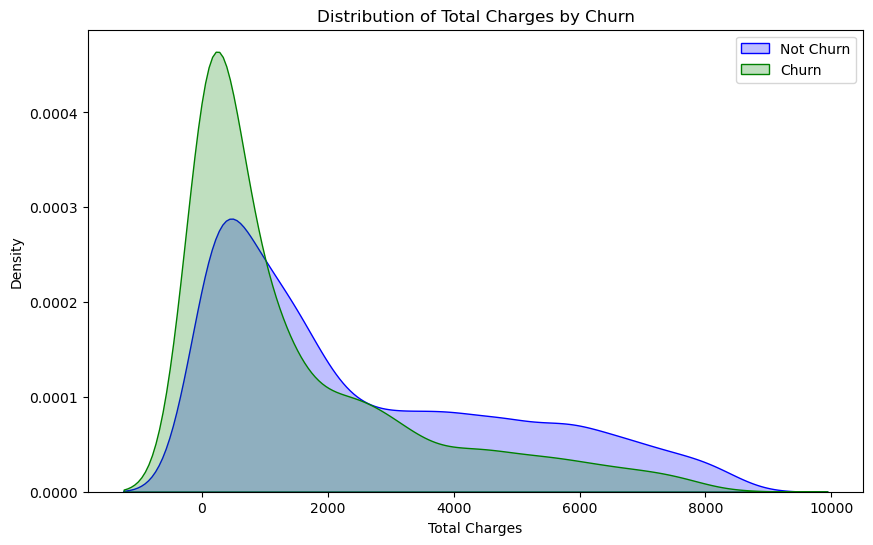

In [32]:
# create distribution charts to determine type of distribution for TotalCharges
import seaborn as sns
plt.figure(figsize=(10,6))
ax = sns.kdeplot(df_churn['TotalCharges'][(df_churn['Churn'] == 'No')], color="Blue", fill=True)
ax = sns.kdeplot(df_churn['TotalCharges'][(df_churn['Churn'] == 'Yes')], ax=ax, color="Green", fill=True)

# create legend, labels, and title for chart, then print
ax.legend(["Not Churn", "Churn"], loc='upper right')
ax.set_xlabel('Total Charges')
ax.set_ylabel('Density')
ax.set_title('Distribution of Total Charges by Churn')
plt.show()

### Create dummy variables if necessary.

In [33]:
# update categorical columns into dummy variables
df_transformed = pd.get_dummies(df_churn, drop_first=True)  # drop_first to drop 1st category to avoid multicollinearity

In [34]:
# show the first 5 rows of the transformed dataset 
df_transformed.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,True,False,True,False,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,True,False,False,False,False,True,False
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,True,False,False,True,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,True,False,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,True,False,True,False,True


In [35]:
# show the new columns
df_transformed.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   SeniorCitizen                          7032 non-null   int64  
 1   tenure                                 7032 non-null   int64  
 2   MonthlyCharges                         7032 non-null   float64
 3   TotalCharges                           7032 non-null   float64
 4   gender_Male                            7032 non-null   bool   
 5   Partner_Yes                            7032 non-null   bool   
 6   Dependents_Yes                         7032 non-null   bool   
 7   PhoneService_Yes                       7032 non-null   bool   
 8   MultipleLines_No phone service         7032 non-null   bool   
 9   MultipleLines_Yes                      7032 non-null   bool   
 10  InternetService_Fiber optic            7032 non-null   bool   
 11  InternetS

# Milestone 3 Begins

In Milestone 3, you will begin the process of selecting, building, and evaluating a model. You are required to train and evaluate at least one model in this milestone. Write step-by-step for performing each of these steps. 

You can use any methods/tools you think are most appropriate, but you should explain/justify why you are selecting the model(s) and evaluation metric(s) you choose. 
- Decision Tree was chosen: to visualize features, using it to get best five features.

- Random Forest was chosen: to reduce overfitting by averaging multiple trees, usually more accurate than a single decision tree. Can handle multiple features.

In [36]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import VarianceThreshold
import matplotlib.pyplot as plt
#import regex
import re

In [37]:
# find detail about columns, including data types
df_transformed.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   SeniorCitizen                          7032 non-null   int64  
 1   tenure                                 7032 non-null   int64  
 2   MonthlyCharges                         7032 non-null   float64
 3   TotalCharges                           7032 non-null   float64
 4   gender_Male                            7032 non-null   bool   
 5   Partner_Yes                            7032 non-null   bool   
 6   Dependents_Yes                         7032 non-null   bool   
 7   PhoneService_Yes                       7032 non-null   bool   
 8   MultipleLines_No phone service         7032 non-null   bool   
 9   MultipleLines_Yes                      7032 non-null   bool   
 10  InternetService_Fiber optic            7032 non-null   bool   
 11  InternetS

In [38]:
# split the data into features and target
features_churn = df_transformed.drop(columns=['Churn_Yes'])
target_churn = df_transformed['Churn_Yes']

In [39]:
# Split the data into training (80%) and test (20%) sets
features_churn_train, features_churn_test, target_churn_train, target_churn_test = train_test_split \
(features_churn, target_churn, test_size=0.2, random_state=42)

In [40]:
target_churn_test.describe()

count      1407
unique        2
top       False
freq       1033
Name: Churn_Yes, dtype: object

In [41]:
df_transformed.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441
std,0.368844,24.545260,30.085974,2266.771362
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.587500,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.862500,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [42]:
df_transformed.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,True,False,True,False,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,True,False,False,False,False,True,False
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,True,False,False,True,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,True,False,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,True,False,True,False,True


### Fit a Decision Tree Classifier on the training set

In [43]:
# fit a Decision Tree Classifier on the training set
clf = DecisionTreeClassifier(random_state=42)
clf.fit(features_churn_train, target_churn_train)

DecisionTreeClassifier(random_state=42)

In [44]:
# predict on the test set
target_churn_pred = clf.predict(features_churn_test)

In [45]:
# report the accuracy, confusion matrix and classification report
accuracy = accuracy_score(target_churn_test, target_churn_pred)
conf_matrix = confusion_matrix(target_churn_test, target_churn_pred)
class_report = classification_report(target_churn_test, target_churn_pred)

In [46]:
# print the results
print(f"Accuracy: {accuracy}")
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"Classification Report:\n{class_report}")

Accuracy: 0.7249466950959488
Confusion Matrix:
[[825 208]
 [179 195]]
Classification Report:
              precision    recall  f1-score   support

       False       0.82      0.80      0.81      1033
        True       0.48      0.52      0.50       374

    accuracy                           0.72      1407
   macro avg       0.65      0.66      0.66      1407
weighted avg       0.73      0.72      0.73      1407



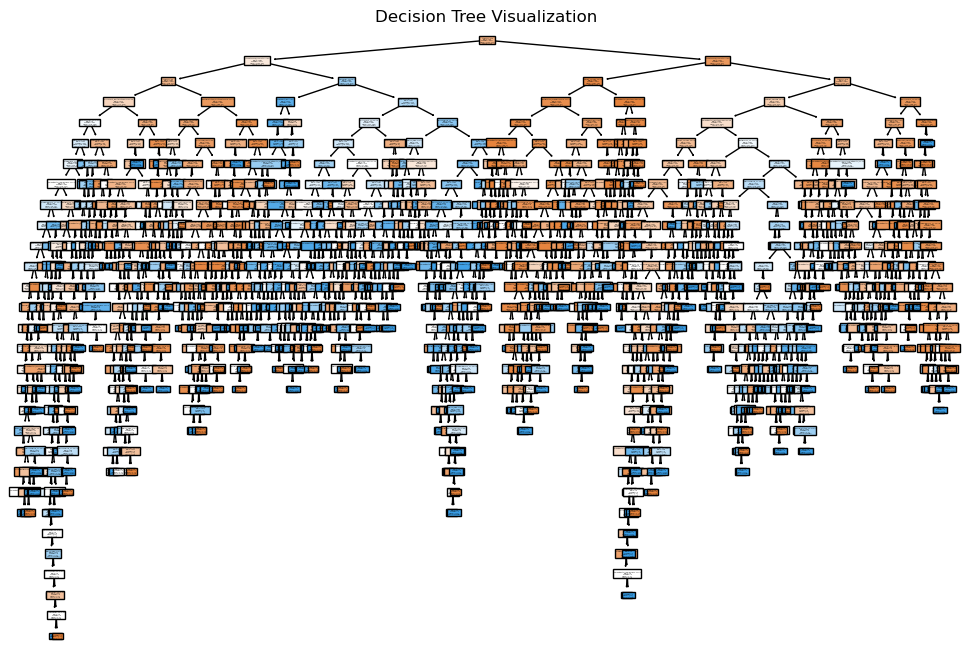

In [47]:
# visualize the Decision Tree
plt.figure(figsize=(12,8))
plot_tree(clf, filled=True, feature_names=features_churn.columns, class_names=['Churn', 'No Churn'])
plt.title("Decision Tree Visualization")
plt.show()

In [48]:
# use χ²-statistic selector to pick the five best features
chi2_selector = SelectKBest(chi2, k=5)
features_churn_train_best = chi2_selector.fit_transform(features_churn_train, target_churn_train)
features_churn_test_best = chi2_selector.transform(features_churn_test)

In [49]:
# find which features were selected using get_support
selected_features = chi2_selector.get_support(indices=True)
selected_feature_names = features_churn.columns[selected_features]

In [50]:
print(f"Selected Features: {selected_feature_names}")

Selected Features: Index(['tenure', 'MonthlyCharges', 'TotalCharges', 'Contract_Two year',
       'PaymentMethod_Electronic check'],
      dtype='object')


In [51]:
# fit a Decision Tree Classifier using the five best features
clf_best = DecisionTreeClassifier(random_state=42)
clf_best.fit(features_churn_train_best, target_churn_train)

DecisionTreeClassifier(random_state=42)

In [52]:
# predict using the selected features
target_churn_pred_best = clf_best.predict(features_churn_test_best)

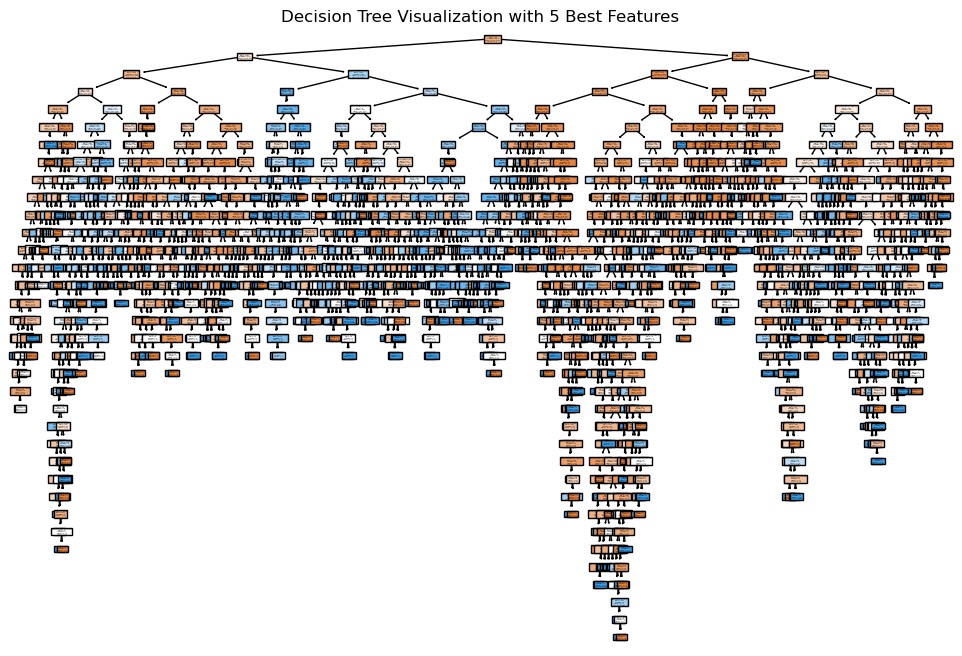

In [53]:
# visualize the Decision Tree with 5 best features
plt.figure(figsize=(12,8))
plot_tree(clf_best, filled=True, feature_names=features_churn.columns, class_names=['Churn', 'No Churn'])
plt.title("Decision Tree Visualization with 5 Best Features")
plt.show()

In [54]:
# report the accuracy and confusion matrix for the model using the five best features
accuracy_best = accuracy_score(target_churn_test, target_churn_pred_best)
conf_matrix_best = confusion_matrix(target_churn_test, target_churn_pred_best)
class_report_best = classification_report(target_churn_test, target_churn_pred_best)

In [55]:
print(f"Accuracy with 5 Best Features: {accuracy_best}")
print(f"Confusion Matrix with 5 Best Features:\n{conf_matrix_best}")
print(f"Classification Report with 5 Best Features:\n{class_report_best}")

Accuracy with 5 Best Features: 0.7242359630419332
Confusion Matrix with 5 Best Features:
[[841 192]
 [196 178]]
Classification Report with 5 Best Features:
              precision    recall  f1-score   support

       False       0.81      0.81      0.81      1033
        True       0.48      0.48      0.48       374

    accuracy                           0.72      1407
   macro avg       0.65      0.65      0.65      1407
weighted avg       0.72      0.72      0.72      1407



In [56]:
print("\nSummary of Findings:")
print(f"Accuracy: {accuracy}")
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"Classification Report:\n{class_report}")
print(f"\n5 Best Features Selected: {selected_feature_names}") 
print(f"Accuracy with 5 Best Features: {accuracy_best}")
print(f"Confusion Matrix with 5 Best Features:\n{conf_matrix_best}")
print(f"Classification Report with 5 Best Features:\n{class_report_best}")


Summary of Findings:
Accuracy: 0.7249466950959488
Confusion Matrix:
[[825 208]
 [179 195]]
Classification Report:
              precision    recall  f1-score   support

       False       0.82      0.80      0.81      1033
        True       0.48      0.52      0.50       374

    accuracy                           0.72      1407
   macro avg       0.65      0.66      0.66      1407
weighted avg       0.73      0.72      0.73      1407


5 Best Features Selected: Index(['tenure', 'MonthlyCharges', 'TotalCharges', 'Contract_Two year',
       'PaymentMethod_Electronic check'],
      dtype='object')
Accuracy with 5 Best Features: 0.7242359630419332
Confusion Matrix with 5 Best Features:
[[841 192]
 [196 178]]
Classification Report with 5 Best Features:
              precision    recall  f1-score   support

       False       0.81      0.81      0.81      1033
        True       0.48      0.48      0.48       374

    accuracy                           0.72      1407
   macro avg       0.

### For the original Decision Tree:
### The accuracy of the random forest model was 72.5% of predictions made by the model were correct.

### The Confusion matrix indicates: 
- 825 non-churn cases were correctly predicted as non-churn (true negatives).
- 208 non-churn cases were considered false alarms (false positives).
- 179 churn cases were considered missed churn cases (false negatives).
- 195 churn cases were correctly predicted as churn (true positives).

### For the best features Decision Tree:
### The five best features are:
- tenure
- MonthlyCharges
- TotalCharges
- Contract_Two year
- PaymentMethod_Electronic check
  
### The accuracy of the random forest model was 72.4% of predictions made by the model were correct.

### The Confusion matrix indicates: 
- 841 non-churn cases were correctly predicted as non-churn (true negatives).
- 192 non-churn cases were considered false alarms (false positives).
- 196 churn cases were considered missed churn cases (false negatives).
- 178 churn cases were correctly predicted as churn (true positives).

### Fit a Random Forest model on the training data

In [57]:
# import required libraries
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [58]:
# split the data into features (X) and target (y)
X = df_transformed.drop(columns=['Churn_Yes'])
y = df_transformed['Churn_Yes']

In [59]:
# Split the data into training (80%) and test (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [60]:
# Initialize the Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Fit the model on the training data
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [61]:
# Make predictions on the test data
y_pred = rf_model.predict(X_test)

# Evaluate model performance
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Classification report and confusion matrix for more detailed evaluation
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.7853589196872779

Classification Report:
               precision    recall  f1-score   support

       False       0.83      0.90      0.86      1033
        True       0.63      0.48      0.54       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.70      1407
weighted avg       0.77      0.79      0.78      1407


Confusion Matrix:
 [[927 106]
 [196 178]]


### The accuracy of the random forest model was 78.54% of predictions made by the model were correct.

### The classification report reflected the following:
#### - For the False class:
- Precision: 83% of the churn predicted as False were actually False.
- Recall: 90% of the False churn were accurately predicted as False.
- F1-score: 0.86, means there is a good balance between precision and recall.
 
#### - For the True class:
- Precision: 63% of the churn predicted as True were actually True.
- Recall: 48% of the True churn were accurately predicted as True.
- F1-score: 54% means that there isn't a good balance and some churn might be missed.

### The Confusion matrix indicates: 
- 927 non-churn cases were correctly predicted as non-churn (true negatives).
- 106 non-churn cases were considered false alarms (false positives).
- 196 churn cases were considered missed churn cases (false negatives).
- 178 churn cases were correctly predicted as churn (true positives).

In [62]:
# Summary of Findings for all three models run
print("\nSummary of Findings:")
print(f"Original Decision Tree Accuracy: {accuracy}")
print(f"Original Decision Tree Confusion Matrix:\n{conf_matrix}")
print(f"Original Decision Tree Classification Report:\n{class_report}")
print(f"\n5 Best Features Selected Decision Tree: {selected_feature_names}") 
print(f"Accuracy with 5 Best Features Decision Tree: {accuracy_best}")
print(f"Confusion Matrix with 5 Best Features Decision Tree:\n{conf_matrix_best}")
print(f"Classification Report with 5 Best Features Decision Tree:\n{class_report_best}")
print("Random Forest Accuracy:", accuracy)
print("\nRandom Forest Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nRandom Forest Classification Report:\n", classification_report(y_test, y_pred))


Summary of Findings:
Original Decision Tree Accuracy: 0.7853589196872779
Original Decision Tree Confusion Matrix:
[[825 208]
 [179 195]]
Original Decision Tree Classification Report:
              precision    recall  f1-score   support

       False       0.82      0.80      0.81      1033
        True       0.48      0.52      0.50       374

    accuracy                           0.72      1407
   macro avg       0.65      0.66      0.66      1407
weighted avg       0.73      0.72      0.73      1407


5 Best Features Selected Decision Tree: Index(['tenure', 'MonthlyCharges', 'TotalCharges', 'Contract_Two year',
       'PaymentMethod_Electronic check'],
      dtype='object')
Accuracy with 5 Best Features Decision Tree: 0.7242359630419332
Confusion Matrix with 5 Best Features Decision Tree:
[[841 192]
 [196 178]]
Classification Report with 5 Best Features Decision Tree:
              precision    recall  f1-score   support

       False       0.81      0.81      0.81      1033
     

In [63]:
## Final Submission

- Per Professor's feedback: "choose classification (not regression models) and classification metrics, e.g., accuracy, precision, recall, f1, and confusion matrices."
- Removed linear regression model and left decision tree and random forest models with confusion matrices and related classification metrics.
- Added classification reports to original decision tree and decision tree with 5 best features in cells 45,46,54,55,56, and 62.